In [ ]:
import pandas as pd

df = pd.read_csv("../data/domain.csv")

df.head()

,id,domain,original_url,label
0,1,garuda368jp.art,https://garuda368jp.art,gambling
1,2,gacor108b.xyz,https://gacor108b.xyz,gambling
2,3,kuda898jepe.online,https://kuda898jepe.online,gambling
3,4,zeus345win.online,https://zeus345win.online,gambling
4,5,zeus138jp.org,https://zeus138jp.org,gambling


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            1500 non-null   int64
 1   domain        1500 non-null   str  
 2   original_url  1500 non-null   str  
 3   label         1500 non-null   str  
dtypes: int64(1), str(3)
memory usage: 47.0 KB


In [3]:
# Cek jumlah baris yang benar-benar duplikat identik di semua kolom
print("Jumlah duplikat keseluruhan:", df.duplicated().sum())

Jumlah duplikat keseluruhan: 0


# EDA

--- Distribusi Label ---
label
gambling        750
non-gambling    750
Name: count, dtype: int64

--- Persentase Label (%) ---
label
gambling        50.0
non-gambling    50.0
Name: proportion, dtype: float64


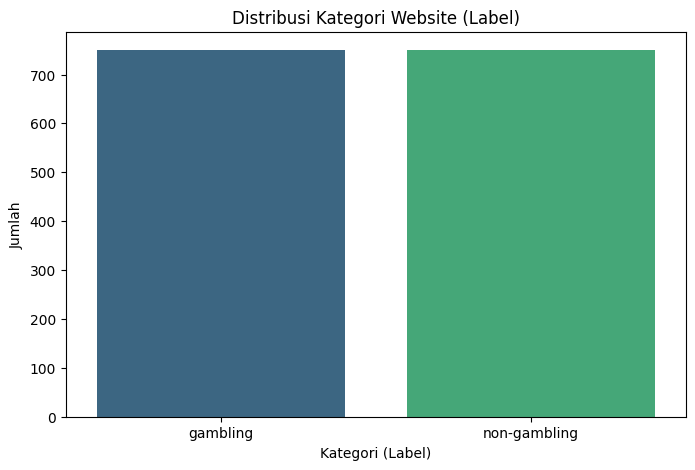

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Melihat jumlah masing-masing kategori pada kolom 'label'
print("--- Distribusi Label ---")
print(df['label'].value_counts())

# 2. Melihat persentasenya
print("\n--- Persentase Label (%) ---")
print(df['label'].value_counts(normalize=True) * 100)

# 3. Membuat visualisasi (Bar Chart)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Distribusi Kategori Website (Label)')
plt.xlabel('Kategori (Label)')
plt.ylabel('Jumlah')
plt.show()

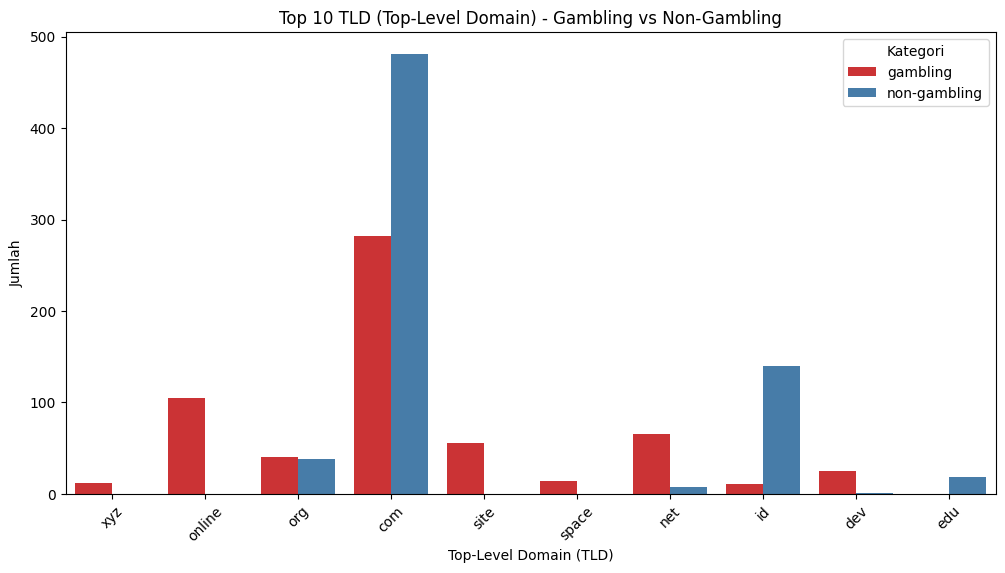

/tmp/ipykernel_253484/2869489897.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='domain_length', palette='Set1')


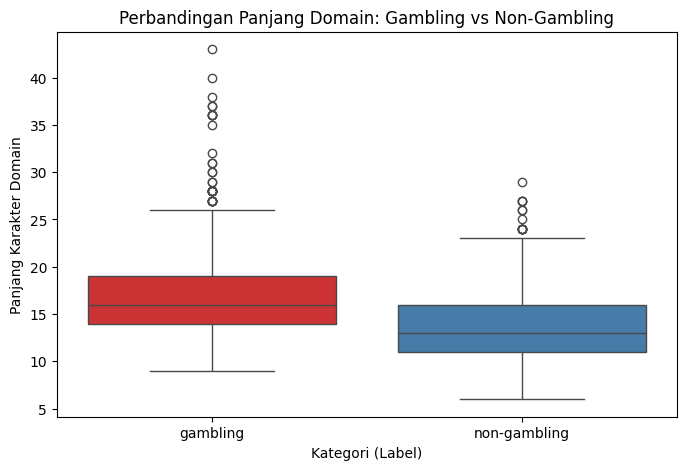

In [5]:
# 1. Mengekstrak TLD (Top-Level Domain)
df['tld'] = df['domain'].apply(lambda x: str(x).split('.')[-1])

# 2. Menghitung panjang nama domain
df['domain_length'] = df['domain'].apply(len)

# 3. Visualisasi Top 10 TLD berdasarkan label
plt.figure(figsize=(12, 6))
# Mengambil 10 TLD terbanyak
top_10_tld = df['tld'].value_counts().nlargest(10).index
sns.countplot(data=df[df['tld'].isin(top_10_tld)], x='tld', hue='label', palette='Set1')
plt.title('Top 10 TLD (Top-Level Domain) - Gambling vs Non-Gambling')
plt.xlabel('Top-Level Domain (TLD)')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.legend(title='Kategori')
plt.show()

# 4. Visualisasi Distribusi Panjang Domain
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='domain_length', palette='Set1')
plt.title('Perbandingan Panjang Domain: Gambling vs Non-Gambling')
plt.xlabel('Kategori (Label)')
plt.ylabel('Panjang Karakter Domain')
plt.show()

1. TLD (Top-Level Domain)
   - Domain Spesifik Judi: Terlihat sangat jelas bahwa TLD murah/unik seperti .online, .site, .space, dan .xyz hampir 100% didominasi oleh label gambling.
   - Domain Terpercaya: Sebaliknya, domain seperti .id (Indonesia) dan .edu (Edukasi) sangat didominasi oleh non-gambling.

2. Panjang Domain
   - Sesuai dugaan kita, box plot menunjukkan bahwa rata-rata domain gambling memang lebih panjang (median sekitar 16 karakter) dibandingkan non-gambling (median sekitar 13 karakter).
   - Banyak sekali titik-titik outlier di atas kotak merah (gambling) yang menunjukkan ada domain judi yang panjangnya ekstrim hingga lebih dari 40 karakter!

/tmp/ipykernel_253484/4196014853.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='num_digits', palette='Set2')


--- Rata-rata Jumlah Angka pada Domain ---
label
gambling        1.541333
non-gambling    0.021333
Name: num_digits, dtype: float64


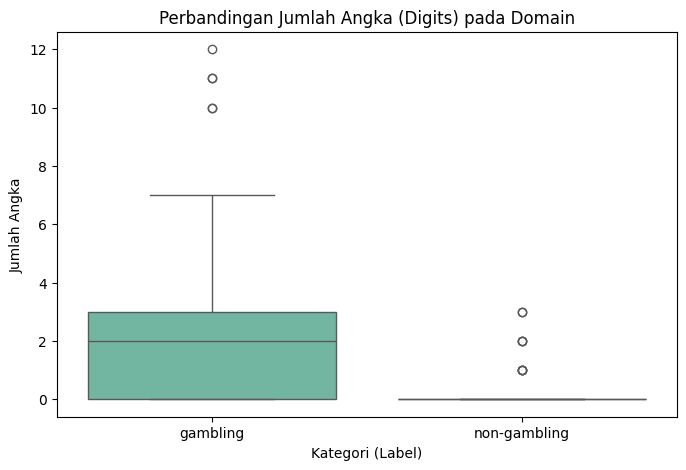

In [6]:
# 1. Membuat kolom baru untuk menghitung jumlah angka (digit) dalam domain
df['num_digits'] = df['domain'].apply(lambda x: sum(c.isdigit() for c in str(x)))

# 2. Melihat rata-rata jumlah angka berdasarkan label
print("--- Rata-rata Jumlah Angka pada Domain ---")
print(df.groupby('label')['num_digits'].mean())

# 3. Visualisasi perbandingan jumlah angka
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='num_digits', palette='Set2')
plt.title('Perbandingan Jumlah Angka (Digits) pada Domain')
plt.xlabel('Kategori (Label)')
plt.ylabel('Jumlah Angka')
plt.show()

Perbedaan antara kedua kategori sangat drastis. Domain non-gambling rata-rata nyaris tidak mengandung angka sama sekali (0.02), dan box plot-nya datar di angka 0. Sebaliknya, domain gambling rata-rata memiliki sekitar 1.5 angka, dengan rentang yang cukup luas bahkan ada yang sampai mengandung 12 angka

--- Top 15 Pola Teks di Domain Gambling ---
   Pola Teks (N-gram)  Frekuensi
0                toto         94
1                slot         65
2                hoki         49
3                toge         49
4                ogel         49
5               togel         49
6                gaco         30
7                acor         30
8               gacor         29
9                dewa         24
10               maxw         18
11               axwi         17
12               xwin         17
13              maxwi         17
14              axwin         17


/tmp/ipykernel_253484/2706546435.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words, x='Frekuensi', y='Pola Teks (N-gram)', palette='Reds_r')


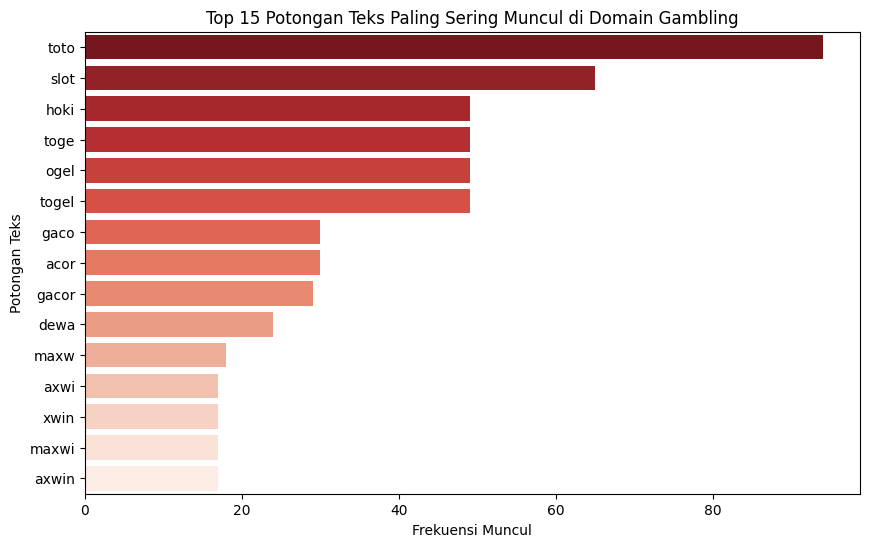

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Membuat kolom nama domain tanpa TLD (contoh: 'garuda368jp.art' -> 'garuda368jp')
# Ini agar kata seperti 'com' atau 'xyz' tidak ikut terhitung sebagai kata kunci
df['domain_name'] = df['domain'].apply(lambda x: str(x).split('.')[0])

# 2. Memfilter hanya data 'gambling' untuk melihat karakteristik kata mereka
gambling_domains = df[df['label'] == 'gambling']['domain_name']

# 3. Menggunakan CountVectorizer untuk mencari potongan 4-5 huruf yang sering muncul (Character N-gram)
vectorizer = CountVectorizer(ngram_range=(4, 5), analyzer='char')
X_gambling = vectorizer.fit_transform(gambling_domains)

# 4. Menghitung frekuensi kemunculan pola huruf
sum_words = X_gambling.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# 5. Mengambil 15 pola teratas dan menampilkannya dalam tabel
top_words = pd.DataFrame(words_freq[:15], columns=['Pola Teks (N-gram)', 'Frekuensi'])
print("--- Top 15 Pola Teks di Domain Gambling ---")
print(top_words)

# 6. Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(data=top_words, x='Frekuensi', y='Pola Teks (N-gram)', palette='Reds_r')
plt.title('Top 15 Potongan Teks Paling Sering Muncul di Domain Gambling')
plt.xlabel('Frekuensi Muncul')
plt.ylabel('Potongan Teks')
plt.show()

melihat pola kata yang sangat jelas. Karena kita menggunakan n-gram 4-5 huruf, kata-kata aslinya terpotong, tapi kita bisa dengan mudah menyimpulkan kata kuncinya:

- toto dan slot (Sangat jelas)
- toge, ogel, togel → togel
- gaco, acor, gacor → gacor
- maxw, axwi, xwin, maxwi, axwin → maxwin
- dewa dan hoki

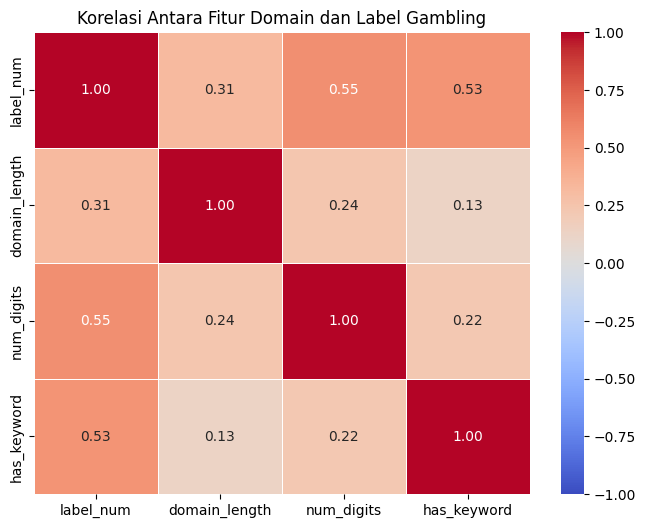

In [8]:
# 1. Mengubah label menjadi numerik (1 = gambling, 0 = non-gambling)
df['label_num'] = df['label'].map({'gambling': 1, 'non-gambling': 0})

# 2. Membuat fitur baru: Apakah domain mengandung kata kunci judi?
# Kita ambil dari hasil analisa N-gram sebelumnya
keywords = ['toto', 'slot', 'hoki', 'togel', 'gacor', 'dewa', 'maxwin']
pattern = '|'.join(keywords) # Menjadi 'toto|slot|hoki|togel|gacor|dewa|maxwin'

# True/False (1/0) jika mengandung salah satu kata di atas
df['has_keyword'] = df['domain'].str.contains(pattern, case=False, na=False).astype(int)

# 3. Menyiapkan dataframe khusus angka untuk korelasi
# Kita ambil fitur-fitur yang sudah kita buat sejauh ini
kolom_numerik = ['label_num', 'domain_length', 'num_digits', 'has_keyword']
df_corr = df[kolom_numerik].corr()

# 4. Visualisasi Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korelasi Antara Fitur Domain dan Label Gambling')
plt.show()

num_digits (Korelasi 0.55)
Fitur ini memiliki korelasi positif paling tinggi. Artinya, semakin banyak angka di dalam sebuah nama domain, semakin besar kemungkinan website tersebut adalah situs gambling.

has_keyword (Korelasi 0.53)
Fitur kata kunci ("slot", "gacor", dll.) menempel ketat di posisi kedua. Jika domain mengandung kata-kata ini, probabilitasnya menjadi situs judi sangat tinggi.

domain_length (Korelasi 0.31)
Panjang domain memiliki korelasi yang lumayan (sedang). Domain judi memang cenderung lebih panjang, tetapi fitur ini tidak sekuat dua fitur sebelumnya.

In [9]:
df.head()

,id,domain,original_url,label,tld,domain_length,num_digits,domain_name,label_num,has_keyword
0,1,garuda368jp.art,https://garuda368jp.art,gambling,art,15,3,garuda368jp,1,0
1,2,gacor108b.xyz,https://gacor108b.xyz,gambling,xyz,13,3,gacor108b,1,1
2,3,kuda898jepe.online,https://kuda898jepe.online,gambling,online,18,3,kuda898jepe,1,0
3,4,zeus345win.online,https://zeus345win.online,gambling,online,17,3,zeus345win,1,0
4,5,zeus138jp.org,https://zeus138jp.org,gambling,org,13,3,zeus138jp,1,0


In [10]:
from sklearn.model_selection import train_test_split

# 1. Menentukan Fitur (X) dan Target/Label (y)
# Kita gunakan fitur dengan korelasi yang baik, yaitu 'num_digits' dan 'has_keyword'
X = df[['num_digits', 'has_keyword']]
y = df['label_num']

# 2. Membagi data (80% training, 20% testing)
# stratify=y memastikan rasio judi dan non-judi tetap seimbang 50:50 di data latih maupun data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Mengecek ukuran data setelah dibagi
print("Ukuran Fitur Data Latih (X_train):", X_train.shape)
print("Ukuran Label Data Latih (y_train):", y_train.shape)
print("Ukuran Fitur Data Uji (X_test):", X_test.shape)
print("Ukuran Label Data Uji (y_test):", y_test.shape)

Ukuran Fitur Data Latih (X_train): (1200, 2)
Ukuran Label Data Latih (y_train): (1200,)
Ukuran Fitur Data Uji (X_test): (300, 2)
Ukuran Label Data Uji (y_test): (300,)


--- Hasil Pertandingan Berbagai Model ---
Logistic Regression: 89.33%
Decision Tree: 89.33%
Random Forest: 89.33%
Support Vector Machine (SVM): 89.33%
K-Nearest Neighbors (KNN): 89.33%
Naive Bayes: 87.33%
Gradient Boosting: 89.33%
Neural Network (MLP): 89.33%


/tmp/ipykernel_253484/998218724.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Akurasi', y='Model', palette='magma')


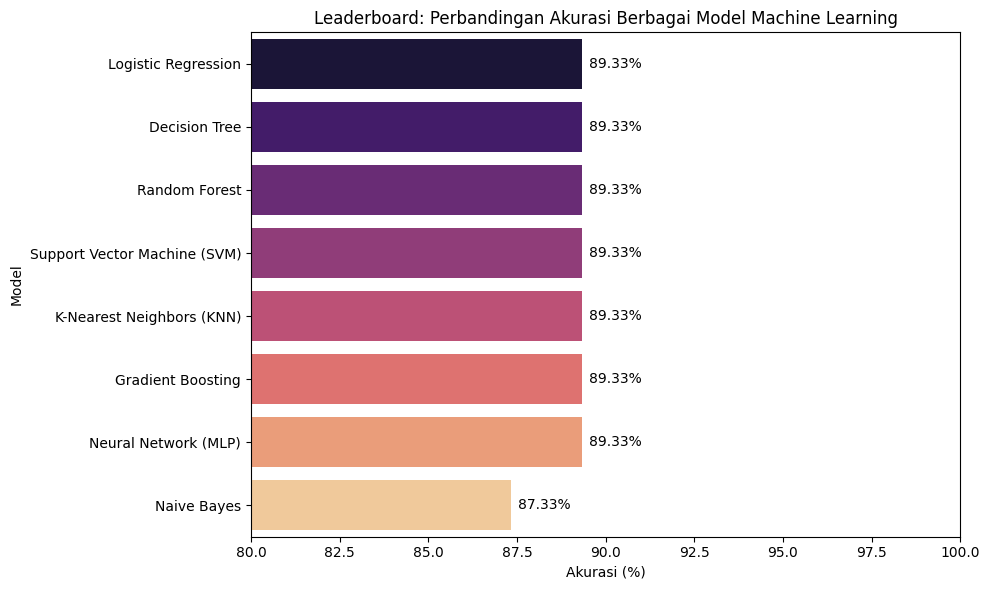

In [11]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Menyiapkan lebih banyak "peserta" model
extended_models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine (SVM)": SVC(random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=1000)
}

# 2. Melatih dan menguji setiap model
results = []
print("--- Hasil Pertandingan Berbagai Model ---")
for name, model in extended_models.items():
    # Melatih model
    model.fit(X_train, y_train)
    # Memprediksi
    y_pred = model.predict(X_test)
    # Menghitung akurasi
    akurasi = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Akurasi": akurasi * 100})
    print(f"{name}: {akurasi * 100:.2f}%")

# 3. Membuat DataFrame Leaderboard dan mengurutkannya
df_results = pd.DataFrame(results).sort_values(by="Akurasi", ascending=False)

# 4. Visualisasi Perbandingan Model (Leaderboard)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Akurasi', y='Model', palette='magma')
plt.title('Leaderboard: Perbandingan Akurasi Berbagai Model Machine Learning')
plt.xlabel('Akurasi (%)')
plt.ylabel('Model')
plt.xlim(80, 100) # Membatasi sumbu X agar perbedaan kecil terlihat jelas

# Menambahkan angka persentase di ujung tiap bar
for index, value in enumerate(df_results['Akurasi']):
    plt.text(value + 0.2, index, f'{value:.2f}%', va='center')

plt.tight_layout()
plt.show()

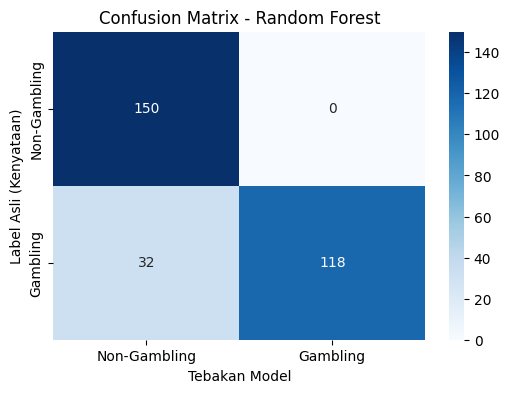

/tmp/ipykernel_253484/882424623.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=X.columns, palette='viridis')


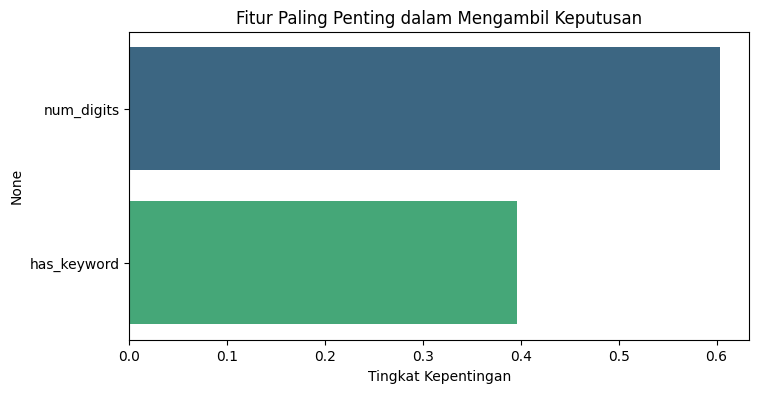

--- UJI COBA DETEKSI URL ---
Detail: shopee.com, Jumlah Angka: 0, Kata Kunci Judi: Tidak
🔗 URL: https://shopee.com
🤖 Hasil Deteksi: 🟢 AMAN (Tingkat Keyakinan: 83.25%)

Detail: youtube.com, Jumlah Angka: 0, Kata Kunci Judi: Tidak
🔗 URL: https://www.youtube.com
🤖 Hasil Deteksi: 🟢 AMAN (Tingkat Keyakinan: 83.25%)

Detail: tokopedia.com, Jumlah Angka: 0, Kata Kunci Judi: Tidak
🔗 URL: https://tokopedia.com
🤖 Hasil Deteksi: 🟢 AMAN (Tingkat Keyakinan: 83.25%)

Detail: garuda368jp.art, Jumlah Angka: 3, Kata Kunci Judi: Tidak
🔗 URL: https://garuda368jp.art
🤖 Hasil Deteksi: 🔴 JUDI ONLINE (Tingkat Keyakinan: 98.12%)

Detail: maxslot88kita.xyz, Jumlah Angka: 2, Kata Kunci Judi: Ya
🔗 URL: https://maxslot88kita.xyz
🤖 Hasil Deteksi: 🔴 JUDI ONLINE (Tingkat Keyakinan: 100.00%)

Detail: kampusmerdeka.kemdikbud.go.id, Jumlah Angka: 0, Kata Kunci Judi: Tidak
🔗 URL: https://kampusmerdeka.kemdikbud.go.id
🤖 Hasil Deteksi: 🟢 AMAN (Tingkat Keyakinan: 83.25%)

Detail: berikan-aku-10-link.netlify.app, Jumlah Ang

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. Menetapkan Juara dan Melatih Ulang (untuk memastikan)
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# 2. Membuat Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Gambling', 'Gambling'], 
            yticklabels=['Non-Gambling', 'Gambling'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Label Asli (Kenyataan)')
plt.xlabel('Tebakan Model')
plt.show()

# 3. Melihat "Fitur Favorit" dari Random Forest (Feature Importance)
importances = best_model.feature_importances_
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=X.columns, palette='viridis')
plt.title('Fitur Paling Penting dalam Mengambil Keputusan')
plt.xlabel('Tingkat Kepentingan')
plt.show()

# =========================================================
# 4. MEMBUAT FUNGSI DETEKSI URL OTOMATIS
# =========================================================
def deteksi_website(url):
    # Membersihkan URL untuk mengambil domainnya saja
    domain = url.split('//')[-1].split('/')[0].split('www.')[-1]
    
    # Ekstrak 2 Fitur Utama persis seperti saat EDA
    n_digits = sum(c.isdigit() for c in domain)
    
    keywords = ['toto', 'slot', 'hoki', 'togel', 'gacor', 'dewa', 'maxwin']
    has_kw = int(any(kw in domain.lower() for kw in keywords))

    print(f"Detail: {domain}, Jumlah Angka: {n_digits}, Kata Kunci Judi: {'Ya' if has_kw else 'Tidak'}")
    
    # Memasukkan ke dalam format yang dipahami model
    data_baru = pd.DataFrame([[n_digits, has_kw]], 
                             columns=['num_digits', 'has_keyword'])
    
    # Menyuruh model menebak
    prediksi = best_model.predict(data_baru)[0]
    probabilitas = best_model.predict_proba(data_baru)[0][prediksi] * 100
    
    # Menampilkan Hasil
    status = "🔴 JUDI ONLINE" if prediksi == 1 else "🟢 AMAN"
    print(f"🔗 URL: {url}")
    print(f"🤖 Hasil Deteksi: {status} (Tingkat Keyakinan: {probabilitas:.2f}%)\n")

# Mari kita tes dengan URL bebas!
print("--- UJI COBA DETEKSI URL ---")
deteksi_website("https://shopee.com")
deteksi_website("https://www.youtube.com")
deteksi_website("https://tokopedia.com")
deteksi_website("https://garuda368jp.art")
deteksi_website("https://maxslot88kita.xyz")
deteksi_website("https://kampusmerdeka.kemdikbud.go.id")
deteksi_website("https://berikan-aku-10-link.netlify.app")
deteksi_website("https://gustoristobar.com")
deteksi_website("https://hargayin.com")
deteksi_website("https://www.liputan6.com")

# Alternatif fitur

1. Umur Domain (Domain Age) — [PILIHAN TERBAIK SAAT INI]
* Kelebihan: Akurasi sangat tinggi (situs judi biasanya baru berumur beberapa hari/minggu sebelum diblokir).
* Kekurangan: Terkadang data WHOIS disembunyikan (meskipun status "disembunyikan" itu sendiri sudah mencurigakan).
* Trade-off: Sangat Cepat & Murah. Banyak *library* Python atau API gratis untuk mengecek ini.

2. Lokasi IP Server (GeoIP)
* Kelebihan: Akurasi tinggi. Jika URL-nya berbahasa Indonesia tapi servernya di Kamboja atau Curacao, itu sangat mencurigakan.
* Kekurangan: Pembuat situs bisa menyamarkan lokasi menggunakan layanan seperti Cloudflare.
* Trade-off: Cepat & Gratis. Bisa menggunakan database lokal (seperti MaxMind) tanpa perlu koneksi API luar.

3. Cek Isi Konten (Web Scraping)
* Kelebihan: Paling akurat karena langsung membaca isi teks di dalam website (mencari kata deposit, rtp, dll).
* Kekurangan: Sangat Lambat & Berat. Sistem Anda harus "mengunjungi" web tersebut, yang memakan waktu dan memori, serta rentan diblokir oleh sistem *anti-bot*.
* Trade-off: Kurang efisien untuk mengecek ribuan URL secara bersamaan.
